**Week 5 Jupyter Notebook**

Support Vector Machines (SVM), Kernel Trick, and Regularization
Integrated Capstone

**Project:** Systemic Banking Risk Assessment

**Objective**

The objective of this notebook is to develop Support Vector Machine (SVM) models for predicting loan default using borrower demographic and financial information. The analysis compares a linear SVM with nonlinear kernel SVMs (RBF and Polynomial) and investigates how the regularization parameter (C) influences classification performance. The results are evaluated using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC.





In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
# Load the Cleaned Dataset

credit_risk = pd.read_csv("credit_risk_cleaned.csv")

credit_risk.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Select Features

features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

X = credit_risk[features]

y = credit_risk['loan_status']

In [4]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
# Linear SVM

linear_svm = SVC(
    kernel='linear',
    C=1,
    probability=True,
    random_state=42
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

linear_pred = linear_svm.predict(
    X_test_scaled
)

print(classification_report(
    y_test,
    linear_pred
))

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        linear_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      5066
           1       0.75      0.33      0.45      1418

    accuracy                           0.83      6484
   macro avg       0.79      0.65      0.68      6484
weighted avg       0.82      0.83      0.80      6484

Accuracy: 0.8288093769278223


In [7]:
# RBF Kernel (Kernel Trick)

rbf_svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

rbf_svm.fit(
    X_train_scaled,
    y_train
)

rbf_pred = rbf_svm.predict(
    X_test_scaled
)

print(classification_report(
    y_test,
    rbf_pred
))

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rbf_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      5066
           1       0.77      0.43      0.55      1418

    accuracy                           0.85      6484
   macro avg       0.81      0.70      0.73      6484
weighted avg       0.84      0.85      0.83      6484

Accuracy: 0.8471622455274522


In [8]:
# Polynomial Kernel

poly_svm = SVC(
    kernel='poly',
    degree=3,
    C=1,
    probability=True,
    random_state=42
)

poly_svm.fit(
    X_train_scaled,
    y_train
)

poly_pred = poly_svm.predict(
    X_test_scaled
)

print(classification_report(
    y_test,
    poly_pred
))

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        poly_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      5066
           1       0.79      0.33      0.47      1418

    accuracy                           0.83      6484
   macro avg       0.81      0.65      0.68      6484
weighted avg       0.83      0.83      0.81      6484

Accuracy: 0.8343615052436767


In [9]:
# Effect of Regularization (C)

C_values = [0.01, 0.1, 1, 10, 100]

accuracy = []

for c in C_values:

    svm = SVC(
        kernel='rbf',
        C=c,
        probability=True,
        random_state=42
    )

    svm.fit(
        X_train_scaled,
        y_train
    )

    pred = svm.predict(
        X_test_scaled
    )

    accuracy.append(
        accuracy_score(
            y_test,
            pred
        )
    )

results = pd.DataFrame({
    'C':C_values,
    'Accuracy':accuracy
})

print(results)

        C  Accuracy
0    0.01  0.818014
1    0.10  0.840993
2    1.00  0.847162
3   10.00  0.852714
4  100.00  0.854874


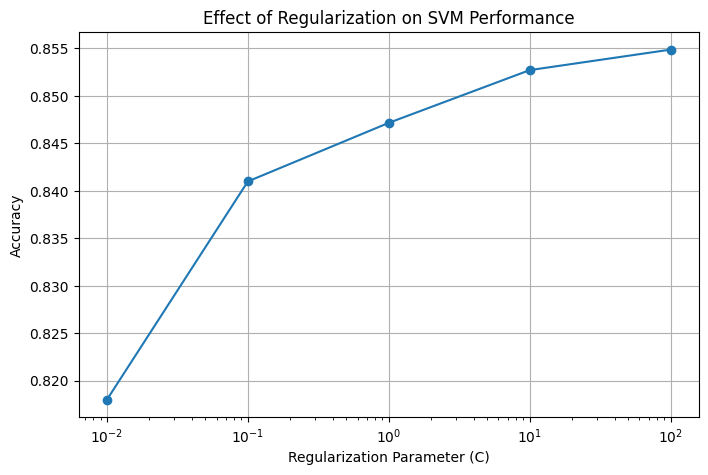

In [10]:
# Plot Regularization Results

plt.figure(figsize=(8,5))

plt.plot(
    C_values,
    accuracy,
    marker='o'
)

plt.xscale('log')

plt.xlabel("Regularization Parameter (C)")

plt.ylabel("Accuracy")

plt.title(
    "Effect of Regularization on SVM Performance"
)

plt.grid(True)

plt.show()

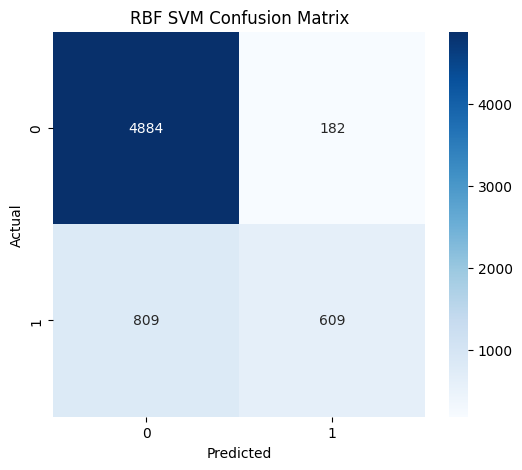

In [11]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    rbf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "RBF SVM Confusion Matrix"
)

plt.show()

AUC: 0.8361025855046252


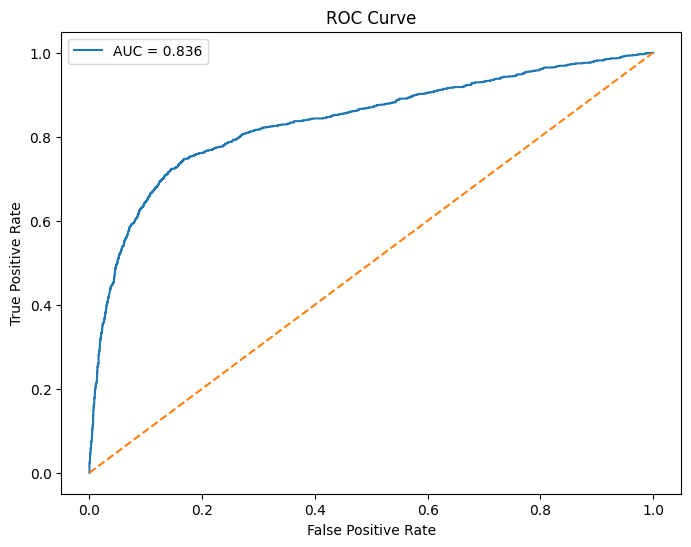

In [12]:
# ROC Curve

prob = rbf_svm.predict_proba(
    X_test_scaled
)[:,1]

auc = roc_auc_score(
    y_test,
    prob
)

print("AUC:", auc)

fpr, tpr, _ = roc_curve(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [13]:
# Compare All Models

comparison = pd.DataFrame({

    'Model':[
        'Linear SVM',
        'RBF Kernel',
        'Polynomial Kernel'
    ],

    'Accuracy':[

        accuracy_score(
            y_test,
            linear_pred
        ),

        accuracy_score(
            y_test,
            rbf_pred
        ),

        accuracy_score(
            y_test,
            poly_pred
        )
    ]
})

comparison

,Model,Accuracy
0,Linear SVM,0.828809
1,RBF Kernel,0.847162
2,Polynomial Kernel,0.834362


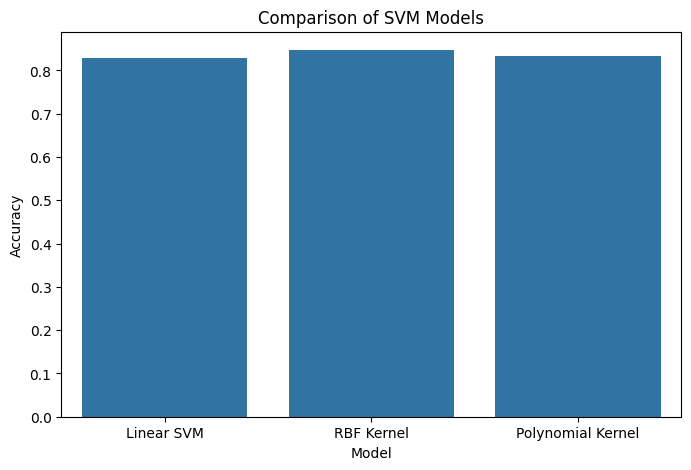

In [14]:
# Model Comparison Plot

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title(
    "Comparison of SVM Models"
)

plt.show()

**Conclusion**

The objective of Week 5 was to evaluate the performance of Support Vector Machine (SVM) classifiers for predicting loan default using borrower demographic and financial characteristics. Three SVM models were compared: Linear SVM, Radial Basis Function (RBF) Kernel SVM, and Polynomial Kernel SVM. In addition, the effect of the regularization parameter (C) was examined to determine the optimal balance between model complexity and predictive performance.

The Linear SVM achieved an overall accuracy of 82.88%, with a precision of 0.75, recall of 0.33, and an F1-score of 0.45 for the default class. While the model classified non-default borrowers very well (precision = 0.84, recall = 0.97), its relatively low recall for default cases indicates that many defaulting borrowers were incorrectly classified as non-default.

The RBF Kernel SVM produced the strongest overall performance, achieving an accuracy of 84.72%, with a precision of 0.77, recall of 0.43, and an F1-score of 0.55 for the default class. Compared with the Linear SVM, the RBF model improved the identification of defaulting borrowers while maintaining strong performance for non-default borrowers. The model also achieved an AUC of 0.8361, demonstrating good discrimination between borrowers who default and those who do not. These results suggest that the nonlinear relationships captured by the RBF kernel provide a more accurate representation of borrower behavior than a purely linear decision boundary.

The Polynomial Kernel SVM achieved an accuracy of 83.44%, with a precision of 0.79, recall of 0.33, and an F1-score of 0.47 for the default class. Although it slightly improved precision compared with the Linear SVM, its recall remained relatively low, indicating that it still struggled to correctly identify borrowers who defaulted.

The analysis of the regularization parameter (C) showed a steady improvement in model performance as C increased. Accuracy improved from 81.80% (C = 0.01) to 85.49% (C = 100), suggesting that a larger penalty for classification errors allowed the model to better fit the data without substantial overfitting.

Overall, the results demonstrate that the RBF Kernel SVM is the most effective classifier among the three models evaluated. The kernel trick enabled the model to capture complex nonlinear relationships between borrower characteristics and default risk, resulting in improved predictive performance. Although all models performed well in identifying non-default borrowers, detecting default cases remained more challenging because of class imbalance. These findings highlight the effectiveness of nonlinear SVMs for credit risk prediction and demonstrate the importance of selecting an appropriate kernel and regularization parameter to maximize classification performance.